## Lab10

In this assignment, you will perform **PCA** and **K-Means clustering** on the following simulated data:

    np.random.seed(1)

    X = np.random.normal(size=(60, 50))

    X[20:40] = X[20:40] + np.array([0.5]*50)

    X[40:60] = X[40:60] + np.array([-0.5]*50)

This can be interpreted as a data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.

In [1]:
# Import your libraries here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

In [2]:
# Simulated Data
np.random.seed(1)
X = np.random.normal(size=(60,50))
X[20:40] = X[20:40] + np.array([0.5]*50)
X[40:60] = X[40:60] + np.array([-0.5]*50)

labels = np.zeros(60)
labels[20:40] = 1
labels[40:60] = 2

**(a) Perform PCA on the 60 observations and plot the first two principal
component score vectors. Use a different color to indicate
the observations in each of the three classes.**

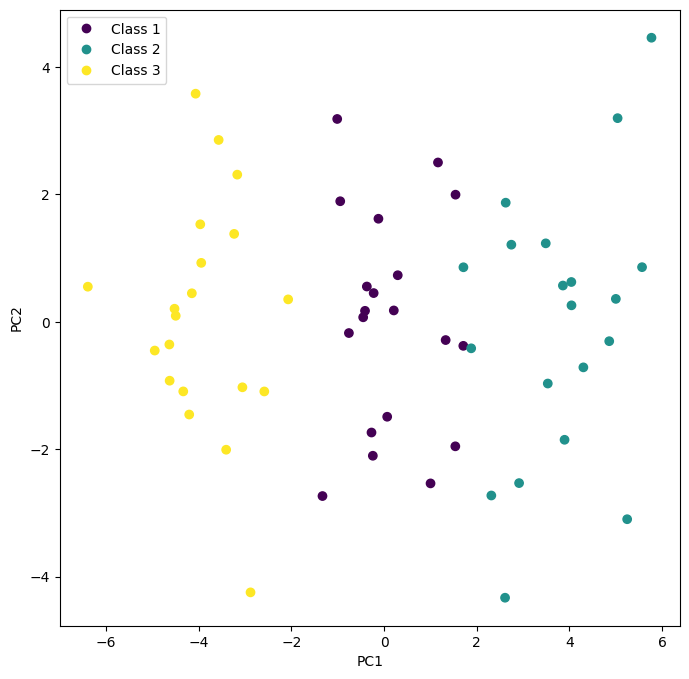

In [3]:
pcaX = PCA()
scores = pcaX.fit_transform(X)

i, j = 0, 1
fig,ax = plt.subplots(1, 1, figsize=(8,8))
scatter = ax.scatter(scores[:,0], scores[:,1], c=labels, cmap='viridis')
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))

legend_labels = ['Class 1', 'Class 2', 'Class 3']
handles = [plt.Line2D([], [], marker='o', linestyle='', color = scatter.cmap(scatter.norm(k))) for k in range(3)]
ax.legend(handles, legend_labels, loc='best')
plt.show()

**(b) Perform K-means clustering of the observations with K = 3 and plot the first two principal component score vectors, this time using colors based on the class labels obtained by clustering. (Use `random_state=1` and `n_init=20`.)**

**Also, use the `pd.crosstab()` function in Python to compare
the true class labels to the class labels obtained by clustering.
Be careful how you interpret the results: K-means clustering
will arbitrarily number the clusters, so you cannot simply check
whether the true class labels and clustering labels are the same.**

**How well do the clusters that you obtained in K-means clustering
compare to the true class labels?**

col_0  0.0  1.0  2.0
row_0               
0       16    1    2
1        3   19    0
2        1    0   18


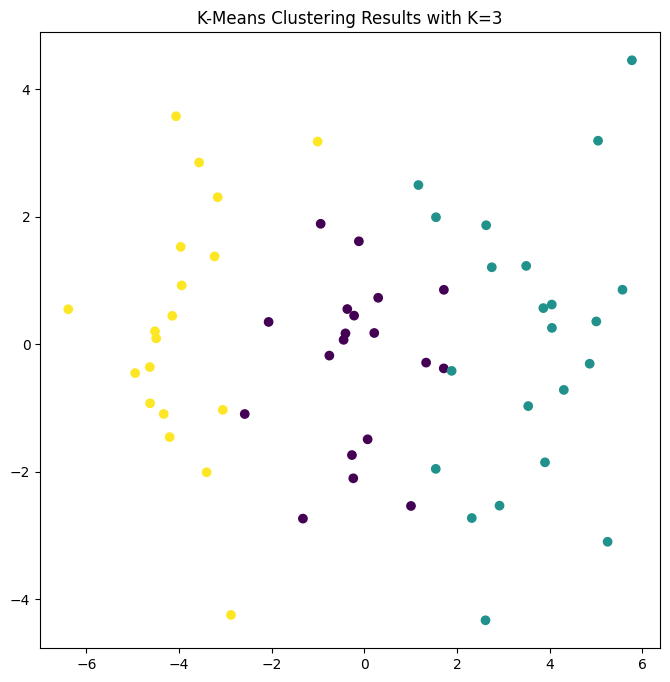

In [4]:
kmeans_3 = KMeans(n_clusters=3,
                  random_state=1,
                  n_init=20).fit(X)

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(scores[:,0], scores[:,1], c=kmeans_3.labels_)
ax.set_title("K-Means Clustering Results with K=3")

crosstab = pd.crosstab(kmeans_3.labels_, labels)
print(crosstab)

(Write your comments in this Markdown cell)

The k=3 model is very accurate with an accuracy of around 88.33% (53/60). This shows that the k_means cluster labels are pretty close to the real clusters.

**(c) Repeat (b) with K=2**

col_0  0.0  1.0  2.0
row_0               
0        6   20    0
1       14    0   20


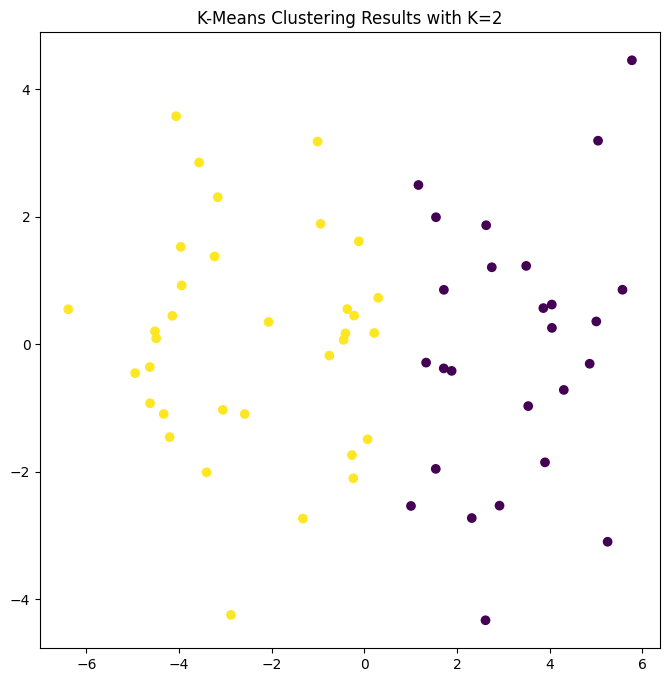

In [5]:
kmeans_2 = KMeans(n_clusters=2,
                  random_state=1,
                  n_init=20).fit(X)

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(scores[:,0], scores[:,1], c=kmeans_2.labels_)
ax.set_title("K-Means Clustering Results with K=2")

print(pd.crosstab(kmeans_2.labels_, labels))

(Write your comments in this Markdown cell)

When repeating this with k=2, the middle cluster was divided into the others based almost entirely on the PCA1 variable. This is interesting as this model was trained on the raw X, but as we can see in the graph(using pca values) it is still divided by the principal components.

**(d) Now repeat (b) *on the first two
principal component score vectors*, rather than on the raw data.
That is, perform K-means clustering with K=3 on the 60 × 2 matrix of
which the first column is the first principal component score
vector, and the second column is the second principal component
score vector. Comment on the results.**

col_0  0.0  1.0  2.0
row_0               
0        0   18    0
1        0    0   20
2       20    2    0


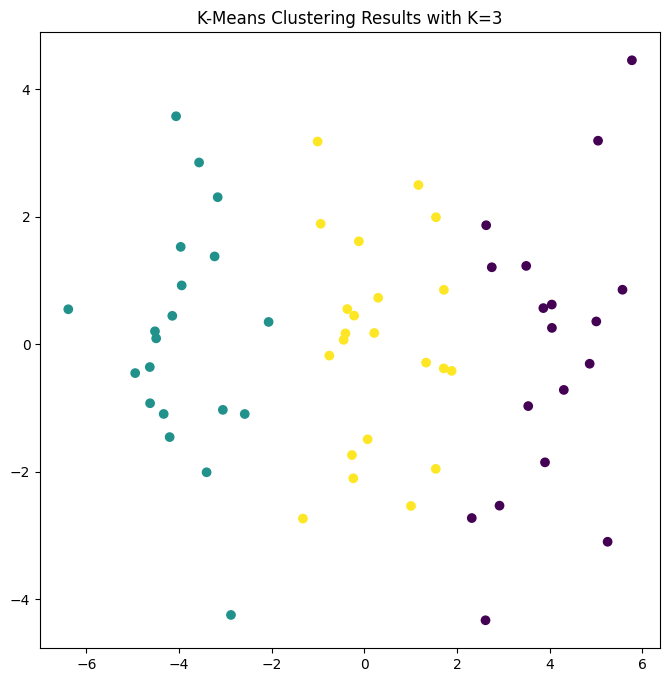

In [6]:
scores_2d = scores[:,:2]

kmeans_3_pc2 = KMeans(n_clusters=3,
                  random_state=1,
                  n_init=20).fit(scores_2d)

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(scores_2d[:,0], scores_2d[:,1], c=kmeans_3_pc2.labels_)
ax.set_title("K-Means Clustering Results with K=3")

print(pd.crosstab(kmeans_3_pc2.labels_, labels))

(Write your comments in this Markdown cell)

The K-means models on the first two principle components matches very closely to the true labels, achieving an accuracy of 96.57% (58/60). This shows improvement from the model that trained on the raw data.